In [ ]:
import cv2
import easyocr
import re

reader = easyocr.Reader(['id','en'])

(np.float64(-0.5), np.float64(1023.5), np.float64(663.5), np.float64(-0.5))

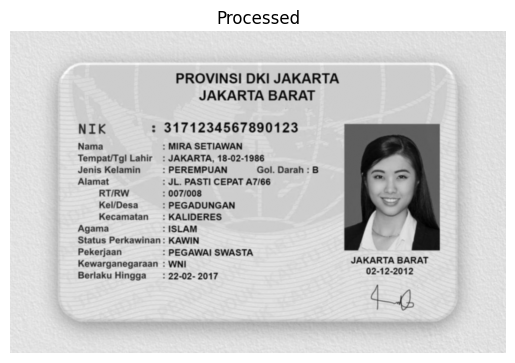

In [3]:
img = cv2.imread("data/sample_ktp.jpg")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (3,3), 0)

import matplotlib.pyplot as plt
plt.imshow(blur, cmap='gray')
plt.title("Processed")
plt.axis('off')

In [4]:
results = reader.readtext(blur)

raw_text = " ".join([r[1] for r in results])
print(raw_text)

PROVINSI DKI JAKARTA JAKARTA BARAT NIK 3171234567890123 Nama MIRA SETIAWAN TempatTgl Lahir JAKARTA, 18-02-1986 Jenis Kelamin PEREMPUAN Gol. Darah Alamat JL: PASTI CEPAT A7/66 RTIRW 007/008 KellDesa PEGADUNGAN Kecamatan KALIDERES Agama ISLAM Status Perkawinan KAWIN Pekerjaan PEGAWAI SWASTA Kewarganegaraan WNI JAKARTA BARAT Berlaku Hingga 22-02- 2017 02-12-2012


In [6]:
clean = raw_text.upper()

clean = clean.replace("TEMPATTGL", "TEMPAT TGL")
clean = clean.replace("RTIRW", "RT RW")
clean = clean.replace("KELLDESA", "KEL/DESA")

print(clean)

PROVINSI DKI JAKARTA JAKARTA BARAT NIK 3171234567890123 NAMA MIRA SETIAWAN TEMPAT TGL LAHIR JAKARTA, 18-02-1986 JENIS KELAMIN PEREMPUAN GOL. DARAH ALAMAT JL: PASTI CEPAT A7/66 RT RW 007/008 KEL/DESA PEGADUNGAN KECAMATAN KALIDERES AGAMA ISLAM STATUS PERKAWINAN KAWIN PEKERJAAN PEGAWAI SWASTA KEWARGANEGARAAN WNI JAKARTA BARAT BERLAKU HINGGA 22-02- 2017 02-12-2012


In [7]:
nik = re.findall(r'\d{16}', raw_text)
nik = nik[0] if nik else None

print("NIK:", nik)

NIK: 3171234567890123


In [8]:
nama = None

match = re.search(r'NAMA\s+([A-Z\s]+?)\s+TEMPAT', clean)
if match:
    nama = match.group(1)

print("Nama:", nama)

Nama: MIRA SETIAWAN


In [9]:
tempat = None
tanggal = None

match = re.search(r'([A-Z]+),\s*(\d{2}-\d{2}-\d{4})', clean)
if match:
    tempat = match.group(1)
    tanggal = match.group(2)

print("Tempat:", tempat)
print("Tanggal:", tanggal)

Tempat: JAKARTA
Tanggal: 18-02-1986


In [ ]:
jk = None

if "LAKI" in clean:
    jk = "Laki-laki"
elif "PEREMPUAN" in clean:
    jk = "Perempuan"

print("Jenis Kelamin:", jk)

JK: Perempuan


In [12]:
alamat = None

match = re.search(r'ALAMAT\s+(.+?)(RT|KEL|KECAMATAN|AGAMA)', clean)
if match:
    alamat = match.group(1).strip()
    alamat = alamat.replace("  ", " ")

print("Alamat:", alamat)

Alamat: JL: PASTI CEPAT A7/66


In [13]:
output = {
    "nik": nik,
    "nama": nama,
    "tempat_lahir": tempat,
    "tanggal_lahir": tanggal,
    "jenis_kelamin": jk,
    "alamat": alamat
}

print("\nFINAL OUTPUT:\n", output)


FINAL OUTPUT:
 {'nik': '3171234567890123', 'nama': 'MIRA SETIAWAN', 'tempat_lahir': 'JAKARTA', 'tanggal_lahir': '18-02-1986', 'jenis_kelamin': 'Perempuan', 'alamat': 'JL: PASTI CEPAT A7/66'}
